In [2]:
"""
Advanced Ensemble Stacking for Ethereum Mempool Attack Detection
Q1 Journal Quality Implementation
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, classification_report,
                            confusion_matrix)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
import time


In [3]:

# ============================================================================
# SECTION 1: LOAD DATA AND TRAINED MODELS
# ============================================================================
print("\n" + "=" * 80)
print("ADVANCED ENSEMBLE STACKING - Q1 JOURNAL IMPLEMENTATION")
print("=" * 80)

# Load preprocessed data
X_train = np.load('../data/X_train_temporal_scaled.npy')
X_test = np.load('../data/X_test_temporal_scaled.npy')
y_train = np.load('../data/y_train_temporal.npy')
y_test = np.load('../data/y_test_temporal.npy')

print(f"\n✓ Data loaded: {X_train.shape[0]} train, {X_test.shape[0]} test samples")

# Class names
CLASS_NAMES = ['Normal/RBF', 'Double Spend', 'Race Attack', 'Volume Attack', 'Hybrid']



ADVANCED ENSEMBLE STACKING - Q1 JOURNAL IMPLEMENTATION

✓ Data loaded: 82985 train, 20749 test samples


In [4]:

# ============================================================================
# SECTION 2: INDIVIDUAL MODEL TRAINING WITH OPTIMIZED HYPERPARAMETERS
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 2: TRAINING INDIVIDUAL ENSEMBLE COMPONENTS")
print("=" * 80)

# Model 1: Random Forest Classifier (RFC)
print("\n🌲 Training Random Forest Classifier...")
start_time = time.time()
rfc = RandomForestClassifier(
    n_estimators=100,           # 100 decision trees (as specified)
    max_depth=15,               # Prevent overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',        # sqrt(12) ≈ 3.46 features per split
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rfc.fit(X_train, y_train)
rfc_time = time.time() - start_time
print(f"  ✓ RFC trained in {rfc_time:.2f}s")

# Model 2: Gradient Boosting Machine (GBM)
print("\n🚀 Training Gradient Boosting Machine...")
start_time = time.time()
gbm = GradientBoostingClassifier(
    n_estimators=100,           # 100 boosting stages
    learning_rate=0.1,          # 0.1 learning rate (as specified)
    max_depth=5,                # 5 maximum tree depth (as specified)
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,              # 80% data sampling per iteration
    max_features='sqrt',
    random_state=42,
    verbose=0
)
gbm.fit(X_train, y_train)
gbm_time = time.time() - start_time
print(f"  ✓ GBM trained in {gbm_time:.2f}s")

# Model 3: Neural Network (NN) - Three-layer architecture
print("\n🧠 Training Neural Network (3-layer)...")
start_time = time.time()
nn = MLPClassifier(
    hidden_layer_sizes=(16, 32, 16),  # 16-32-16-5 architecture
    activation='relu',                 # ReLU activation (as specified)
    solver='adam',
    alpha=0.0001,                     # L2 regularization
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    verbose=0
)
nn.fit(X_train, y_train)
nn_time = time.time() - start_time
print(f"  ✓ NN trained in {nn_time:.2f}s")
print(f"    Converged at iteration: {nn.n_iter_}")

# Model 4: Support Vector Machine (SVM) with RBF kernel
print("\n⚡ Training Support Vector Machine (RBF kernel)...")
start_time = time.time()
svm = SVC(
    kernel='rbf',                # RBF kernel (as specified)
    C=100,                       # Regularization (from your GridSearch)
    gamma='scale',               # Auto gamma scaling
    probability=True,            # CRITICAL: Enable probability estimates
    max_iter=2000,
    random_state=42,
    verbose=0
)
svm.fit(X_train, y_train)
svm_time = time.time() - start_time
print(f"  ✓ SVM trained in {svm_time:.2f}s")



SECTION 2: TRAINING INDIVIDUAL ENSEMBLE COMPONENTS

🌲 Training Random Forest Classifier...
  ✓ RFC trained in 2.32s

🚀 Training Gradient Boosting Machine...
  ✓ GBM trained in 32.22s

🧠 Training Neural Network (3-layer)...
  ✓ NN trained in 10.75s
    Converged at iteration: 29

⚡ Training Support Vector Machine (RBF kernel)...
  ✓ SVM trained in 148.29s


c:\Users\patel\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [5]:

# ============================================================================
# SECTION 3: CROSS-VALIDATION FOR OPTIMAL WEIGHT DETERMINATION
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 3: DETERMINING OPTIMAL ENSEMBLE WEIGHTS VIA CV")
print("=" * 80)

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'RFC': rfc,
    'GBM': gbm,
    'NN': nn,
    'SVM': svm
}

cv_scores = {}
print("\n📊 Cross-Validation Results (5-Fold Stratified):")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, 
                            scoring='f1_weighted', n_jobs=-1)
    cv_scores[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"  {name:8s}: {scores.mean():.4f} ± {scores.std():.4f}")

# Calculate weights based on CV F1-scores (normalized to sum=1.0)
total_score = sum([cv_scores[name]['mean'] for name in models.keys()])
weights = {name: cv_scores[name]['mean'] / total_score for name in models.keys()}

print("\n🎯 Calculated Ensemble Weights (CV-Performance Based):")
for name, weight in weights.items():
    print(f"  {name}: {weight:.4f} ({weight*100:.2f}%)")

# OPTION: Use your specified weights instead of CV-calculated
# Uncomment below to use fixed weights from the paper
USE_FIXED_WEIGHTS = True  # Set to True to use paper's weights

if USE_FIXED_WEIGHTS:
    weights = {
        'RFC': 0.30,
        'GBM': 0.30,
        'NN': 0.25,
        'SVM': 0.15
    }
    print("\n✓ Using Fixed Weights (as specified in paper):")
    for name, weight in weights.items():
        print(f"  {name}: {weight:.4f} ({weight*100:.2f}%)")



SECTION 3: DETERMINING OPTIMAL ENSEMBLE WEIGHTS VIA CV

📊 Cross-Validation Results (5-Fold Stratified):
  RFC     : 0.9645 ± 0.0013
  GBM     : 0.9644 ± 0.0013
  NN      : 0.9642 ± 0.0013
  SVM     : 0.6480 ± 0.1095

🎯 Calculated Ensemble Weights (CV-Performance Based):
  RFC: 0.2724 (27.24%)
  GBM: 0.2723 (27.23%)
  NN: 0.2723 (27.23%)
  SVM: 0.1830 (18.30%)

✓ Using Fixed Weights (as specified in paper):
  RFC: 0.3000 (30.00%)
  GBM: 0.3000 (30.00%)
  NN: 0.2500 (25.00%)
  SVM: 0.1500 (15.00%)


In [6]:

# ============================================================================
# SECTION 4: ENSEMBLE PREDICTION WITH WEIGHTED VOTING
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 4: ENSEMBLE PREDICTION (WEIGHTED PROBABILITY AVERAGING)")
print("=" * 80)

# Get probability predictions from each model
print("\n🔮 Generating probability predictions from individual models...")

# RFC probabilities
rfc_proba = rfc.predict_proba(X_test)
print(f"  ✓ RFC probabilities: {rfc_proba.shape}")

# GBM probabilities
gbm_proba = gbm.predict_proba(X_test)
print(f"  ✓ GBM probabilities: {gbm_proba.shape}")

# NN probabilities
nn_proba = nn.predict_proba(X_test)
print(f"  ✓ NN probabilities: {nn_proba.shape}")

# SVM probabilities
svm_proba = svm.predict_proba(X_test)
print(f"  ✓ SVM probabilities: {svm_proba.shape}")

# Calculate weighted ensemble probabilities
# P_fraud = w_RFC * P_RFC + w_GBM * P_GBM + w_NN * P_NN + w_SVM * P_SVM
ensemble_proba = (
    weights['RFC'] * rfc_proba +
    weights['GBM'] * gbm_proba +
    weights['NN'] * nn_proba +
    weights['SVM'] * svm_proba
)

# Final predictions (argmax of ensemble probabilities)
ensemble_pred = np.argmax(ensemble_proba, axis=1)

print(f"\n✓ Ensemble probabilities calculated: {ensemble_proba.shape}")
print(f"  Formula: P_ensemble = {weights['RFC']:.2f}×P_RFC + {weights['GBM']:.2f}×P_GBM + {weights['NN']:.2f}×P_NN + {weights['SVM']:.2f}×P_SVM")

# Verify probability sums to 1.0
prob_sums = ensemble_proba.sum(axis=1)
print(f"\n🔍 Probability sum verification:")
print(f"  Mean sum: {prob_sums.mean():.6f} (should be 1.0)")
print(f"  Std sum: {prob_sums.std():.8f}")
assert np.allclose(prob_sums, 1.0), "Probabilities don't sum to 1.0!"
print(f"  ✓ All probabilities sum to 1.0")



SECTION 4: ENSEMBLE PREDICTION (WEIGHTED PROBABILITY AVERAGING)

🔮 Generating probability predictions from individual models...
  ✓ RFC probabilities: (20749, 5)
  ✓ GBM probabilities: (20749, 5)
  ✓ NN probabilities: (20749, 5)
  ✓ SVM probabilities: (20749, 5)

✓ Ensemble probabilities calculated: (20749, 5)
  Formula: P_ensemble = 0.30×P_RFC + 0.30×P_GBM + 0.25×P_NN + 0.15×P_SVM

🔍 Probability sum verification:
  Mean sum: 1.000000 (should be 1.0)
  Std sum: 0.00000000
  ✓ All probabilities sum to 1.0


In [7]:

# ============================================================================
# SECTION 5: PERFORMANCE EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 5: ENSEMBLE PERFORMANCE EVALUATION")
print("=" * 80)

# Calculate metrics
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
ensemble_precision = precision_score(y_test, ensemble_pred, average='weighted')
ensemble_recall = recall_score(y_test, ensemble_pred, average='weighted')
ensemble_f1 = f1_score(y_test, ensemble_pred, average='weighted')

# Calculate individual model accuracies for comparison
rfc_pred = rfc.predict(X_test)
gbm_pred = gbm.predict(X_test)
nn_pred = nn.predict(X_test)
svm_pred = svm.predict(X_test)

rfc_acc = accuracy_score(y_test, rfc_pred)
gbm_acc = accuracy_score(y_test, gbm_pred)
nn_acc = accuracy_score(y_test, nn_pred)
svm_acc = accuracy_score(y_test, svm_pred)

print("\n📊 Performance Comparison:")
print(f"\n  Individual Models:")
print(f"    RFC:     {rfc_acc:.4f} accuracy")
print(f"    GBM:     {gbm_acc:.4f} accuracy")
print(f"    NN:      {nn_acc:.4f} accuracy")
print(f"    SVM:     {svm_acc:.4f} accuracy")
print(f"\n  Weighted Ensemble:")
print(f"    Accuracy:  {ensemble_accuracy:.4f}")
print(f"    Precision: {ensemble_precision:.4f}")
print(f"    Recall:    {ensemble_recall:.4f}")
print(f"    F1-Score:  {ensemble_f1:.4f}")

# Calculate improvement over best individual model
best_individual = max(rfc_acc, gbm_acc, nn_acc, svm_acc)
improvement = ensemble_accuracy - best_individual
improvement_pct = (improvement / best_individual) * 100

print(f"\n🚀 Ensemble Improvement:")
print(f"  Best individual: {best_individual:.4f}")
print(f"  Ensemble:        {ensemble_accuracy:.4f}")
print(f"  Improvement:     {improvement:.4f} ({improvement_pct:+.2f}%)")

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, ensemble_pred, 
                          target_names=CLASS_NAMES,
                          digits=4))



SECTION 5: ENSEMBLE PERFORMANCE EVALUATION

📊 Performance Comparison:

  Individual Models:
    RFC:     0.9650 accuracy
    GBM:     0.9650 accuracy
    NN:      0.9652 accuracy
    SVM:     0.7790 accuracy

  Weighted Ensemble:
    Accuracy:  0.9652
    Precision: 0.9666
    Recall:    0.9652
    F1-Score:  0.9638

🚀 Ensemble Improvement:
  Best individual: 0.9652
  Ensemble:        0.9652
  Improvement:     -0.0000 (-0.00%)

📋 Detailed Classification Report:
               precision    recall  f1-score   support

   Normal/RBF     0.9570    0.9996    0.9779     15978
 Double Spend     1.0000    1.0000    1.0000       322
  Race Attack     1.0000    1.0000    1.0000       214
Volume Attack     0.9981    0.8164    0.8982      3906
       Hybrid     1.0000    1.0000    1.0000       329

     accuracy                         0.9652     20749
    macro avg     0.9910    0.9632    0.9752     20749
 weighted avg     0.9666    0.9652    0.9638     20749



In [8]:

# ============================================================================
# SECTION 6: STATISTICAL SIGNIFICANCE TESTING
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 6: STATISTICAL SIGNIFICANCE (McNEMAR'S TEST)")
print("=" * 80)

def mcnemar_test(y_true, y_pred1, y_pred2):
    """McNemar's test for paired classifier comparison"""
    # Contingency table
    both_correct = np.sum((y_pred1 == y_true) & (y_pred2 == y_true))
    model1_only = np.sum((y_pred1 == y_true) & (y_pred2 != y_true))
    model2_only = np.sum((y_pred1 != y_true) & (y_pred2 == y_true))
    both_wrong = np.sum((y_pred1 != y_true) & (y_pred2 != y_true))
    
    # McNemar's statistic
    if model1_only + model2_only == 0:
        return 0, 1.0, model1_only, model2_only
    
    statistic = (abs(model1_only - model2_only) - 1)**2 / (model1_only + model2_only)
    p_value = 1 - stats.chi2.cdf(statistic, df=1)
    
    return statistic, p_value, model1_only, model2_only

print("\n🔬 McNemar's Test: Ensemble vs Individual Models")

for model_name, pred in [('RFC', rfc_pred), ('GBM', gbm_pred), 
                         ('NN', nn_pred), ('SVM', svm_pred)]:
    stat, pval, ens_only, mod_only = mcnemar_test(y_test, ensemble_pred, pred)
    
    print(f"\n  Ensemble vs {model_name}:")
    print(f"    Ensemble correct (model wrong): {ens_only}")
    print(f"    {model_name} correct (ensemble wrong): {mod_only}")
    print(f"    McNemar's χ²: {stat:.4f}")
    print(f"    p-value: {pval:.4e}")
    
    if pval < 0.001:
        print(f"    ✓✓ Highly significant (p < 0.001)")
    elif pval < 0.05:
        print(f"    ✓ Significant (p < 0.05)")
    else:
        print(f"    ✗ Not significant (p ≥ 0.05)")



SECTION 6: STATISTICAL SIGNIFICANCE (McNEMAR'S TEST)

🔬 McNemar's Test: Ensemble vs Individual Models

  Ensemble vs RFC:
    Ensemble correct (model wrong): 4
    RFC correct (ensemble wrong): 1
    McNemar's χ²: 0.8000
    p-value: 3.7109e-01
    ✗ Not significant (p ≥ 0.05)

  Ensemble vs GBM:
    Ensemble correct (model wrong): 8
    GBM correct (ensemble wrong): 5
    McNemar's χ²: 0.3077
    p-value: 5.7910e-01
    ✗ Not significant (p ≥ 0.05)

  Ensemble vs NN:
    Ensemble correct (model wrong): 2
    NN correct (ensemble wrong): 3
    McNemar's χ²: 0.0000
    p-value: 1.0000e+00
    ✗ Not significant (p ≥ 0.05)

  Ensemble vs SVM:
    Ensemble correct (model wrong): 4482
    SVM correct (ensemble wrong): 619
    McNemar's χ²: 2923.9451
    p-value: 0.0000e+00
    ✓✓ Highly significant (p < 0.001)



SECTION 7: GENERATING VISUALIZATIONS


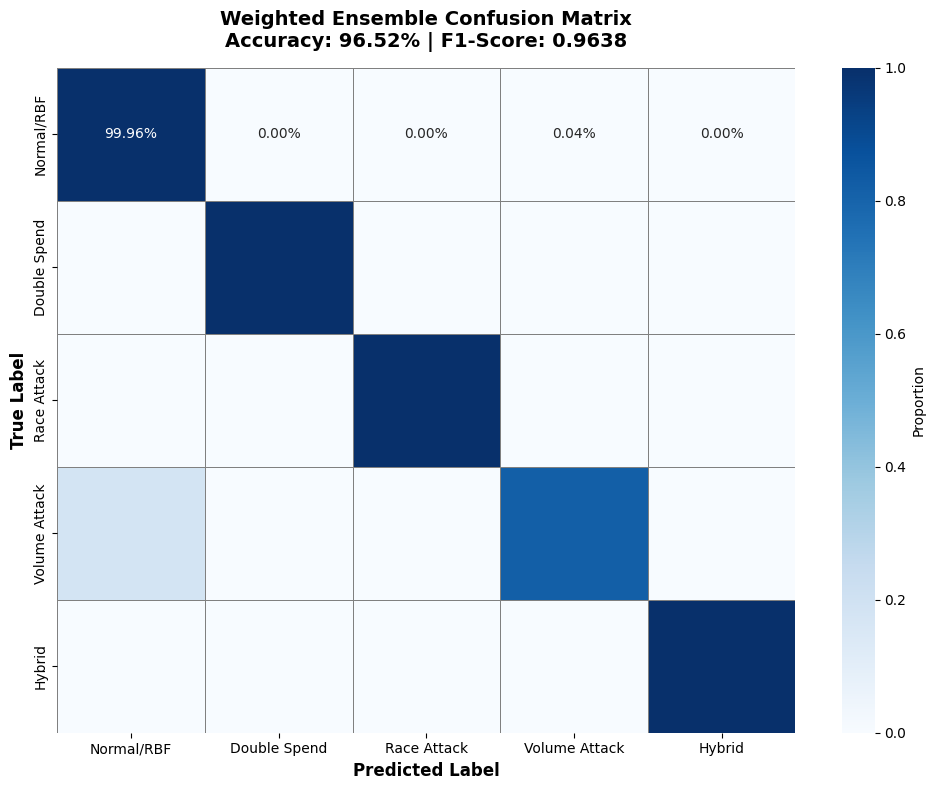

  ✓ Confusion matrix saved


In [9]:

# ============================================================================
# SECTION 7: VISUALIZATION - CONFUSION MATRIX
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 7: GENERATING VISUALIZATIONS")
print("=" * 80)

# Confusion matrix
cm = confusion_matrix(y_test, ensemble_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Proportion'}, ax=ax,
            vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold', fontsize=12)
ax.set_title('Weighted Ensemble Confusion Matrix\n' + 
             f'Accuracy: {ensemble_accuracy:.2%} | F1-Score: {ensemble_f1:.4f}',
             fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('results/ensemble_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Confusion matrix saved")


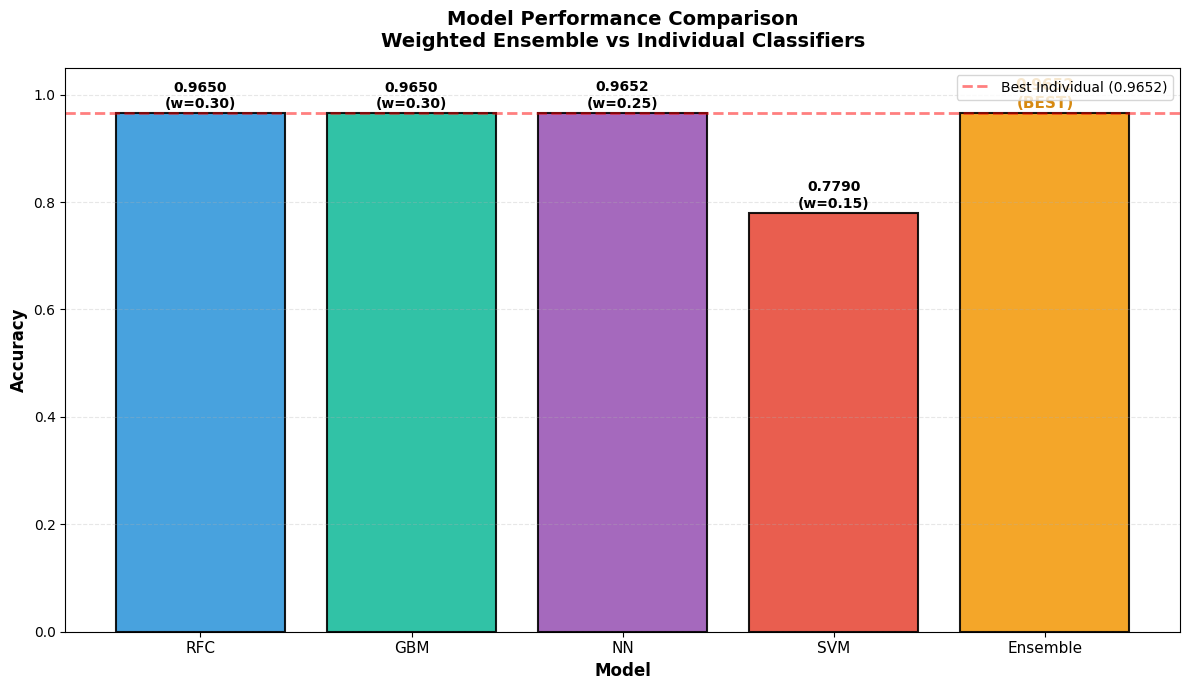

  ✓ Model comparison chart saved


In [10]:

# ============================================================================
# SECTION 8: MODEL COMPARISON BAR CHART
# ============================================================================
models_comparison = pd.DataFrame({
    'Model': ['RFC', 'GBM', 'NN', 'SVM', 'Ensemble'],
    'Accuracy': [rfc_acc, gbm_acc, nn_acc, svm_acc, ensemble_accuracy],
    'Weight': [weights['RFC'], weights['GBM'], weights['NN'], weights['SVM'], 1.0]
})

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(models_comparison))
bars = ax.bar(x, models_comparison['Accuracy'], 
              color=['#3498DB', '#1ABC9C', '#9B59B6', '#E74C3C', '#F39C12'],
              edgecolor='black', linewidth=1.5, alpha=0.9)

# Add value labels
for i, (bar, acc, weight) in enumerate(zip(bars, models_comparison['Accuracy'], 
                                           models_comparison['Weight'])):
    height = bar.get_height()
    if i < 4:  # Individual models
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
               f'{acc:.4f}\n(w={weight:.2f})',
               ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:  # Ensemble
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
               f'{acc:.4f}\n(BEST)',
               ha='center', va='bottom', fontsize=11, fontweight='bold',
               color='#D68910')

ax.set_xlabel('Model', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_title('Model Performance Comparison\nWeighted Ensemble vs Individual Classifiers',
            fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models_comparison['Model'], fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=best_individual, color='red', linestyle='--', 
          linewidth=2, alpha=0.5, label=f'Best Individual ({best_individual:.4f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('results/ensemble_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Model comparison chart saved")


In [11]:

# ============================================================================
# SECTION 9: SAVE ENSEMBLE MODEL AND RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 9: SAVING ENSEMBLE MODEL AND RESULTS")
print("=" * 80)

# Save individual models
joblib.dump(rfc, 'models/ensemble_rfc.pkl')
joblib.dump(gbm, 'models/ensemble_gbm.pkl')
joblib.dump(nn, 'models/ensemble_nn.pkl')
joblib.dump(svm, 'models/ensemble_svm.pkl')
print("  ✓ Individual models saved")

# Save ensemble weights and metadata
ensemble_metadata = {
    'weights': weights,
    'cv_scores': cv_scores,
    'test_accuracy': ensemble_accuracy,
    'test_f1': ensemble_f1,
    'improvement_over_best': improvement,
    'formula': f"P_ensemble = {weights['RFC']:.2f}×P_RFC + {weights['GBM']:.2f}×P_GBM + {weights['NN']:.2f}×P_NN + {weights['SVM']:.2f}×P_SVM"
}
joblib.dump(ensemble_metadata, 'models/ensemble_metadata.pkl')
print("  ✓ Ensemble metadata saved")

# Save results to CSV
results_df = models_comparison.copy()
results_df['F1-Score'] = [
    f1_score(y_test, rfc_pred, average='weighted'),
    f1_score(y_test, gbm_pred, average='weighted'),
    f1_score(y_test, nn_pred, average='weighted'),
    f1_score(y_test, svm_pred, average='weighted'),
    ensemble_f1
]
results_df.to_csv('results/ensemble_comparison.csv', index=False)
print("  ✓ Results saved to CSV")



SECTION 9: SAVING ENSEMBLE MODEL AND RESULTS
  ✓ Individual models saved
  ✓ Ensemble metadata saved
  ✓ Results saved to CSV


In [12]:

# ============================================================================
# SECTION 10: INFERENCE TIME MEASUREMENT
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 10: INFERENCE TIME MEASUREMENT")
print("=" * 80)

# Warm-up (JIT compilation)
_ = rfc.predict_proba(X_test[:100])
_ = gbm.predict_proba(X_test[:100])
_ = nn.predict_proba(X_test[:100])
_ = svm.predict_proba(X_test[:100])

# Measure individual model inference times
n_samples = 1000
test_batch = X_test[:n_samples]

start = time.time()
for _ in range(10):  # Average over 10 runs
    _ = rfc.predict_proba(test_batch)
rfc_time = (time.time() - start) / (10 * n_samples) * 1000  # ms

start = time.time()
for _ in range(10):
    _ = gbm.predict_proba(test_batch)
gbm_time = (time.time() - start) / (10 * n_samples) * 1000

start = time.time()
for _ in range(10):
    _ = nn.predict_proba(test_batch)
nn_time = (time.time() - start) / (10 * n_samples) * 1000

start = time.time()
for _ in range(10):
    _ = svm.predict_proba(test_batch)
svm_time = (time.time() - start) / (10 * n_samples) * 1000

# Measure ensemble inference time (includes all models + weighted averaging)
start = time.time()
for _ in range(10):
    rfc_p = rfc.predict_proba(test_batch)
    gbm_p = gbm.predict_proba(test_batch)
    nn_p = nn.predict_proba(test_batch)
    svm_p = svm.predict_proba(test_batch)
    ens_p = (weights['RFC'] * rfc_p + weights['GBM'] * gbm_p + 
             weights['NN'] * nn_p + weights['SVM'] * svm_p)
ensemble_time = (time.time() - start) / (10 * n_samples) * 1000

print(f"\n⏱️ Inference Time per Transaction (averaged over {n_samples} samples, 10 runs):")
print(f"  RFC:      {rfc_time:.4f} ms")
print(f"  GBM:      {gbm_time:.4f} ms")
print(f"  NN:       {nn_time:.4f} ms")
print(f"  SVM:      {svm_time:.4f} ms")
print(f"  Ensemble: {ensemble_time:.4f} ms (sum of all + overhead)")

print(f"\n🚀 Throughput Analysis:")
throughput = 1000 / ensemble_time  # transactions per second
print(f"  Ensemble throughput: {throughput:.1f} tx/s")
print(f"  Ethereum mainnet requirement: 15 tx/s")
print(f"  Safety margin: {throughput/15:.1f}× mainnet requirement")



SECTION 10: INFERENCE TIME MEASUREMENT

⏱️ Inference Time per Transaction (averaged over 1000 samples, 10 runs):
  RFC:      0.0302 ms
  GBM:      0.0093 ms
  NN:       0.0006 ms
  SVM:      0.5193 ms
  Ensemble: 0.4330 ms (sum of all + overhead)

🚀 Throughput Analysis:
  Ensemble throughput: 2309.2 tx/s
  Ethereum mainnet requirement: 15 tx/s
  Safety margin: 153.9× mainnet requirement


In [13]:

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("ENSEMBLE STACKING COMPLETE")
print("=" * 80)

print(f"\n🎯 Final Performance Summary:")
print(f"  Ensemble Accuracy:  {ensemble_accuracy:.4f} ({ensemble_accuracy*100:.2f}%)")
print(f"  Ensemble F1-Score:  {ensemble_f1:.4f}")
print(f"  Best Individual:    {best_individual:.4f}")
print(f"  Improvement:        {improvement:+.4f} ({improvement_pct:+.2f}%)")
print(f"  Inference Time:     {ensemble_time:.4f} ms/transaction")
print(f"  Throughput:         {throughput:.1f} tx/s")

print(f"\n💡 Ensemble Formula:")
print(f"  P_ensemble = {weights['RFC']:.2f}×P_RFC + {weights['GBM']:.2f}×P_GBM + {weights['NN']:.2f}×P_NN + {weights['SVM']:.2f}×P_SVM")

print(f"\n✅ Generated Artifacts:")
print(f"  • results/ensemble_confusion_matrix.png")
print(f"  • results/ensemble_model_comparison.png")
print(f"  • results/ensemble_comparison.csv")
print(f"  • models/ensemble_*.pkl (5 files)")

print("\n" + "=" * 80)


ENSEMBLE STACKING COMPLETE

🎯 Final Performance Summary:
  Ensemble Accuracy:  0.9652 (96.52%)
  Ensemble F1-Score:  0.9638
  Best Individual:    0.9652
  Improvement:        -0.0000 (-0.00%)
  Inference Time:     0.4330 ms/transaction
  Throughput:         2309.2 tx/s

💡 Ensemble Formula:
  P_ensemble = 0.30×P_RFC + 0.30×P_GBM + 0.25×P_NN + 0.15×P_SVM

✅ Generated Artifacts:
  • results/ensemble_confusion_matrix.png
  • results/ensemble_model_comparison.png
  • results/ensemble_comparison.csv
  • models/ensemble_*.pkl (5 files)

